In [3]:
import numpy as np
import matplotlib.pyplot as plt
from linear_regression import LinearRegression
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

In [4]:
m = 50
x1 = np.random.randint(1, 10, m)
x2 = np.random.randint(50, 65, m)
x3 = np.random.randint(0, 5, m)

X = np.column_stack((x1, x2, x3))

w_true = np.array([2, 3, -1])
b_true = 5

noise = np.random.randn(m) * 0.5
y = X @ w_true + b_true + noise

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50, 3)
y shape: (50,)


In [5]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

In [6]:
model = LinearRegression(
    learning_rate=0.001,
    nb_of_iterations=100_000,
    epsilon=1e-8,
    verbose=True
)
model.fit(X_scaled, y)

Iteration 0, Cost: 16387.189302
Iteration 10000, Cost: 0.294929


In [15]:
y_pred = model.predict(X_scaled)

w_rescaled = model.w / X_std
b_rescaled = model.b - np.sum((model.w * X_mean) / X_std)

print("Real Weights:", w_true)
print("Predicted Weights:", w_rescaled)
print("Real Bias:", b_true)
print("Predicted Bias:", b_rescaled)

Real Weights: [ 2  3 -1]
Predicted Weights: [ 1.9773218   3.00082822 -1.00578142]
Real Bias: 5
Predicted Bias: 5.066253352999638
Training accuracy: 0.0


In [8]:
x_new = np.array([[12, 6, 7]])
x_new_scaled = (x_new - X_mean) / X_std
y_new = model.predict(x_new_scaled)
print("Predicted y for new input:", y_new[0])

Predicted y for new input: 39.758614236714834


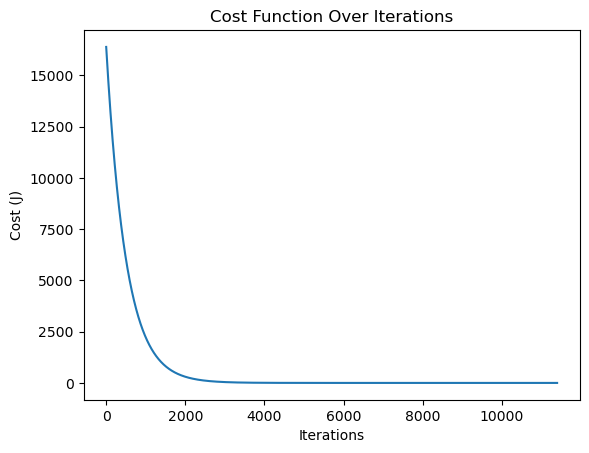

In [9]:
plt.plot(model.cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost (J)")
plt.title("Cost Function Over Iterations")
plt.show()

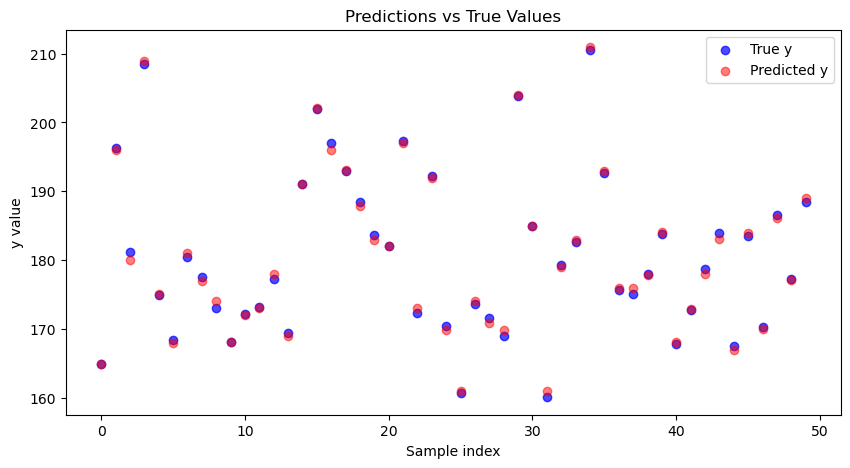

In [10]:
plt.figure(figsize=(10,5))
plt.scatter(range(m), y, color='blue', label='True y', alpha=0.7)
plt.scatter(range(m), y_pred, color='red', label='Predicted y', alpha=0.5)
plt.xlabel('Sample index')
plt.ylabel('y value')
plt.title('Predictions vs True Values')
plt.legend()
plt.show()

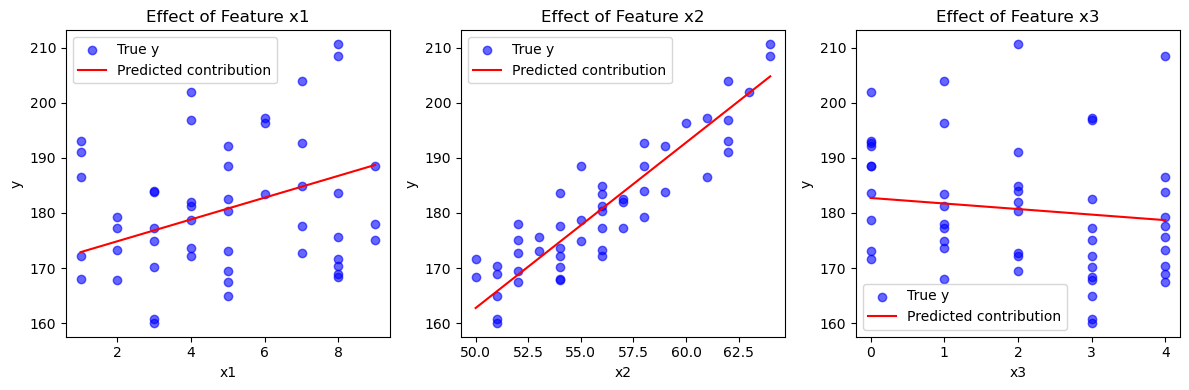

In [11]:
plt.figure(figsize=(12,4))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.scatter(X[:, i], y, color='blue', alpha=0.6, label='True y')
    
    x_vals = np.linspace(X[:, i].min(), X[:, i].max(), 100)
    x_vals_scaled = (x_vals - X_mean[i]) / X_std[i]
    y_vals = x_vals_scaled * model.w[i] + model.b
    plt.plot(x_vals, y_vals, color='red', label='Predicted contribution')
    
    plt.xlabel(f"x{i+1}")
    plt.ylabel("y")
    plt.title(f"Effect of Feature x{i+1}")
    plt.legend()

plt.tight_layout()
plt.show()

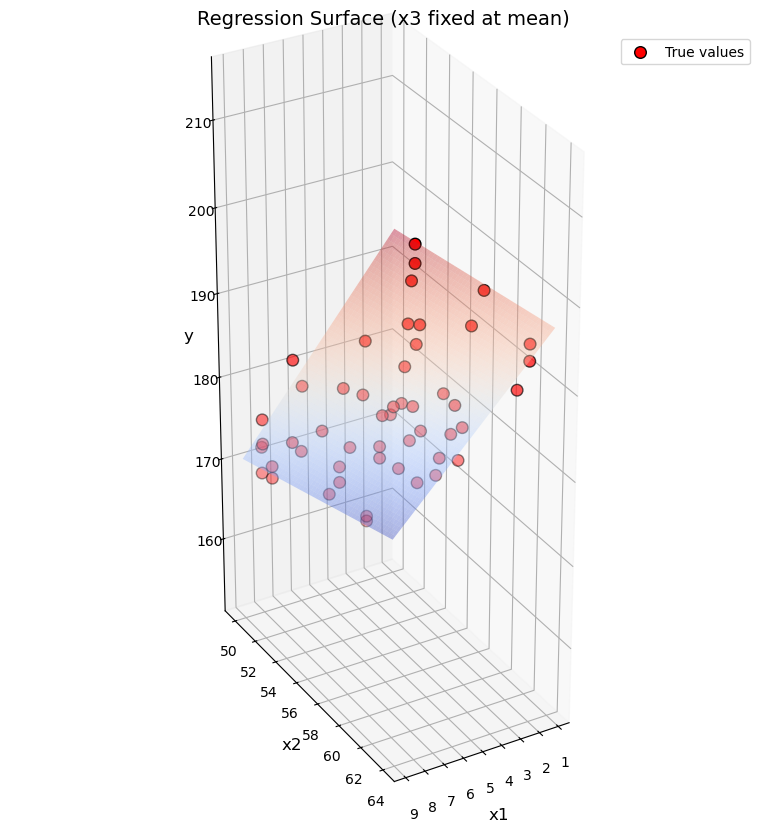

In [12]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')

x1_grid, x2_grid = np.meshgrid(
    np.linspace(X[:,0].min(), X[:,0].max(), 50),
    np.linspace(X[:,1].min(), X[:,1].max(), 50)
)

x3_mean = X[:,2].mean()
X_grid = np.column_stack((
    (x1_grid.ravel() - X_mean[0]) / X_std[0],
    (x2_grid.ravel() - X_mean[1]) / X_std[1],
    np.full_like(x1_grid.ravel(), (x3_mean - X_mean[2]) / X_std[2])
))
y_grid = model.predict(X_grid).reshape(x1_grid.shape)

ax.plot_surface(
    x1_grid, x2_grid, y_grid, 
    alpha=0.4, cmap='coolwarm', edgecolor='none'
)

ax.scatter(X[:,0], X[:,1], y, color='red', s=70, edgecolor='k', label='True values')

ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_zlabel('y', fontsize=12)
ax.set_title('Regression Surface (x3 fixed at mean)', fontsize=14)

ax.view_init(elev=30, azim=60)

ax.set_box_aspect([np.ptp(X[:,0]), np.ptp(X[:,1]), np.ptp(y)/2])

ax.legend()
plt.tight_layout()
plt.show()

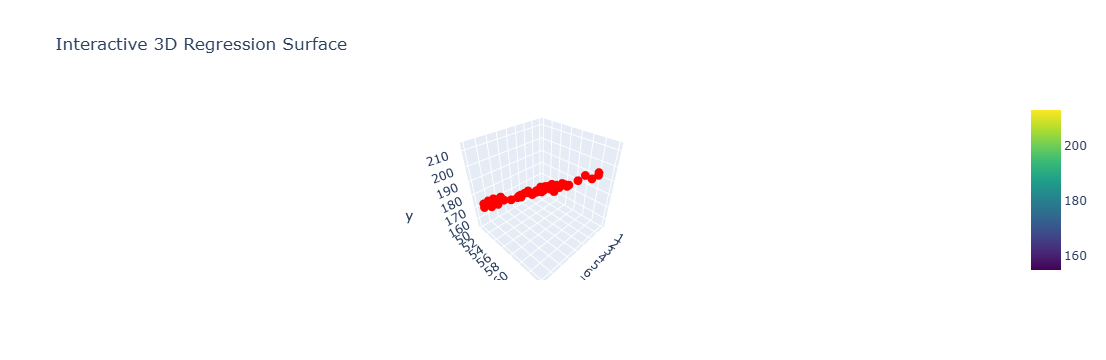

In [14]:
fig = go.Figure()

fig.add_trace(go.Surface(
    x=x1_grid, y=x2_grid, z=y_grid,
    colorscale='Viridis',
    opacity=0.7,
    name='Predicted surface'
))

fig.add_trace(go.Scatter3d(
    x=X[:,0], y=X[:,1], z=y,
    mode='markers',
    marker=dict(size=5, color='red'),
    name='True points'
))

fig.update_layout(
    scene=dict(
        xaxis_title='x1',
        yaxis_title='x2',
        zaxis_title='y',
    ),
    title='Interactive 3D Regression Surface'
)

fig.show()